<h1 align="center" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">
<font color="#A62626">
Transformers in JAX &mdash; Part 5: Generation, Sampling and Scaling at Divar
</font>
</h1>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">
<font color="#A62626">
Part 1 &mdash; The Backstory
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
Four notebooks ago Nika could barely turn a line of Shakespeare into integers, and tonight the same laptop on the fourth floor of <b>Divar</b> holds a small but complete <b>GPT</b> that she trained with her own hands. The model is tiny by industry standards, yet it already spells words, closes quotation marks, and keeps a vaguely Elizabethan rhythm, which is more than enough to make the rest of the platform team curious. Borna, her manager, has noticed the quiet progress and has done something slightly terrifying, namely he has put her on the agenda for the monthly demo day in front of the whole engineering organisation. The brief is short and a little intimidating, because he wants a live demonstration rather than a slide deck, a moment where the model actually writes text on the projector while people watch. Nika knows that training a model and making it speak fluently in front of an audience are two very different skills, and the second one is exactly what she has not built yet. She spends the afternoon before the demo learning how a trained network is coaxed into generating, and that craft is what you build together in this final notebook.
</font>
</p>

<div style="text-align:center;">
    <img src="images/divar-logo.jpg" style="width:100%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">
<font color="#A62626">
Part 2 &mdash; The Mission Brief
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
On demo day the plan is simple to describe and hard to get right, because Nika wants to turn the sampling knobs live and let the audience feel the difference. She will start with the most important dial, the <b>temperature</b>, and show how a low value makes the model cautious and repetitive while a high value makes it adventurous and occasionally unhinged. Then she will introduce the two filters that tame the long tail of unlikely tokens, namely <b>top-k</b> sampling, which keeps only the k most probable next tokens, and <b>top-p</b> or nucleus sampling, which keeps the smallest set of tokens whose probabilities add up past a threshold. The honest question someone in the audience is bound to ask is how far this toy really is from a production <b>GPT</b>, so she prepares a clear answer about <b>scaling</b>, walking from her three-layer MiniGPT up through GPT-2 and on to GPT-3 with its hundreds of billions of parameters. She also wants to explain why generation feels slow and what the <b>KV cache</b> does about it, because the first thing anyone notices live is the pause between tokens. By the end of the notebook the model will not just exist on disk but will speak on command, and Nika will understand every dial she touches.
</font>
</p>

<div style="text-align:center;">
    <img src="images/divar.jpg" style="width:100%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; What you will build in this notebook</h4>
<p style="line-height:180%; font-size:medium;">
This final notebook is about making a trained <b>GPT</b> actually produce text, and about understanding the dials that control how it speaks. We cover six ideas. <b>Autoregressive generation</b> is the loop that feeds the model its own output one token at a time, each step conditioned on everything written so far. <b>Temperature</b> rescales the logits before sampling and is the single most important creativity dial. <b>Top-k sampling</b> keeps only the k most probable tokens and zeroes out the rest, which removes the noisy tail. <b>Top-p (nucleus) sampling</b> keeps the smallest set of tokens whose cumulative probability passes a threshold p, adapting the cut-off to how confident the model is. <b>The KV cache</b> is the engineering trick that explains why naive generation is slow and how production systems speed it up. Finally, <b>scaling laws: from MiniGPT to GPT-3</b> place our tiny model on the same axis as the famous giants, so the gap becomes a concrete number rather than a vague feeling.
</p>
<div style="text-align:center;">
    <img src="images/gpt_logo.svg" style="width:40%;">
</div>

In [1]:
import os, time, math, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

print("JAX", jax.__version__, "| Flax", nn.__version__ if hasattr(nn,"__version__") else "", "| devices:", jax.devices())

JAX 0.10.2 | Flax  | devices: [CpuDevice(id=0)]


In [2]:
# Setup (given): bring forward the MiniGPT model code and the tokenizer from Parts 1-4.

def load_tiny_shakespeare():
    for path in ("data/tiny_shakespeare.txt", "tiny_shakespeare.txt", "../data/tiny_shakespeare.txt"):
        if os.path.exists(path):
            return open(path, encoding="utf-8").read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(url, "data/tiny_shakespeare.txt")
    return open("data/tiny_shakespeare.txt", encoding="utf-8").read()

text = load_tiny_shakespeare()
print(f"Corpus length: {len(text):,} characters")

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

data = np.array(encode(text), dtype=np.int32)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")

def get_batch(key, split, batch_size, block_size):
    source = train_data if split == "train" else val_data
    ix = jax.random.randint(key, (batch_size,), 0, len(source) - block_size - 1)
    ix = np.asarray(ix)
    x = np.stack([source[i:i + block_size] for i in ix])
    y = np.stack([source[i + 1:i + 1 + block_size] for i in ix])
    return jnp.asarray(x), jnp.asarray(y)

class CausalSelfAttention(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        B, T, C = x.shape
        d_head = C // self.n_head
        qkv = nn.Dense(3 * C, use_bias=False, name="qkv")(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        def split_heads(t):
            return t.reshape(B, T, self.n_head, d_head).transpose(0, 2, 1, 3)
        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        scores = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(d_head)
        mask = jnp.tril(jnp.ones((T, T), dtype=bool))
        scores = jnp.where(mask, scores, -1e9)
        attn = jax.nn.softmax(scores, axis=-1)
        attn = nn.Dropout(self.dropout)(attn, deterministic=deterministic)

        out = attn @ v
        out = out.transpose(0, 2, 1, 3).reshape(B, T, C)
        out = nn.Dense(C, name="proj")(out)
        out = nn.Dropout(self.dropout)(out, deterministic=deterministic)
        return out

class TransformerBlock(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        x = x + CausalSelfAttention(self.n_head, self.n_embd, self.dropout)(
            nn.LayerNorm()(x), deterministic)
        h = nn.LayerNorm()(x)
        h = nn.Dense(4 * self.n_embd)(h)
        h = nn.gelu(h)
        h = nn.Dense(self.n_embd)(h)
        h = nn.Dropout(self.dropout)(h, deterministic=deterministic)
        return x + h

class MiniGPT(nn.Module):
    vocab_size: int
    block_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, idx, deterministic=True):
        B, T = idx.shape
        tok = nn.Embed(self.vocab_size, self.n_embd, name="tok_emb")(idx)
        pos = nn.Embed(self.block_size, self.n_embd, name="pos_emb")(jnp.arange(T))
        x = tok + pos[None, :, :]
        x = nn.Dropout(self.dropout)(x, deterministic=deterministic)
        for i in range(self.n_layer):
            x = TransformerBlock(self.n_head, self.n_embd, self.dropout,
                                 name=f"block_{i}")(x, deterministic)
        x = nn.LayerNorm()(x)
        logits = nn.Dense(self.vocab_size, name="head")(x)
        return logits

print('model code ready; vocab_size =', vocab_size)

Corpus length: 1,115,394 characters
train: 1,003,854 tokens | val: 111,540 tokens
model code ready; vocab_size = 65


<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Continuing from Part 4: load the MiniGPT you trained</h4>
<p style="line-height:180%; font-size:medium;">
This notebook does not train a model from scratch; it continues directly from Part 4 (Quera), where you trained a roughly 2.7-million-parameter MiniGPT and saved it to <code>minigpt_ckpt.pkl</code>. The cell below loads that exact checkpoint from the Part 4 folder and rebuilds the model around it, so every sample you generate here comes from the model the previous notebook produced. This is the payoff of a continuous lab: the characters tokenized in Part 1, the attention of Parts 2 and 3, and the training of Part 4 all arrive here as one trained network. If the checkpoint cannot be found (for example if you run this folder on its own), the cell falls back to quickly training a small model so the notebook still works end to end.
</p>
<div style="text-align:center;">
    <img src="images/divar2.jpg" style="width:100%;">
</div>

In [3]:
ckpt_path = None
for _p in ("../04_training_minigpt_quera/minigpt_ckpt.pkl", "minigpt_ckpt.pkl"):
    if os.path.exists(_p):
        ckpt_path = _p
        break

if ckpt_path is not None:
    ck = pickle.load(open(ckpt_path, "rb"))
    cfg = ck["config"]
    params = jax.tree_util.tree_map(jnp.asarray, ck["params"])
    model = MiniGPT(**{**cfg, "dropout": 0.0})
    train_curve = (ck["history"]["steps"], ck["history"]["train"])
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"Loaded the trained MiniGPT from Part 4: {ckpt_path}  ({n_params:,} params)")
else:
    print("Part 4 checkpoint not found - training a small fallback model so this notebook is self-contained ...")
    cfg = dict(vocab_size=vocab_size, block_size=32, n_layer=3, n_head=4, n_embd=96, dropout=0.0)
    model = MiniGPT(**cfg)
    key = jax.random.PRNGKey(0)
    params = model.init(key, jnp.zeros((1, cfg["block_size"]), jnp.int32))
    tx = optax.chain(optax.clip_by_global_norm(1.0), optax.adamw(3e-3, weight_decay=0.1))
    opt_state = tx.init(params)
    def _loss(p, x, y):
        return optax.softmax_cross_entropy_with_integer_labels(model.apply(p, x), y).mean()
    @jax.jit
    def _step(p, os, x, y):
        l, g = jax.value_and_grad(_loss)(p, x, y); u, os = tx.update(g, os, p)
        return optax.apply_updates(p, u), os, l
    steps_log, loss_log = [], []
    for step in range(1200):
        key, sk = jax.random.split(key)
        xb, yb = get_batch(sk, "train", 32, cfg["block_size"])
        params, opt_state, l = _step(params, opt_state, xb, yb)
        if step % 100 == 0:
            steps_log.append(step); loss_log.append(float(l))
    train_curve = (steps_log, loss_log)
    print("fallback model trained; final loss:", float(l))

Loaded the trained MiniGPT from Part 4: minigpt_ckpt.pkl  (2,703,425 params)


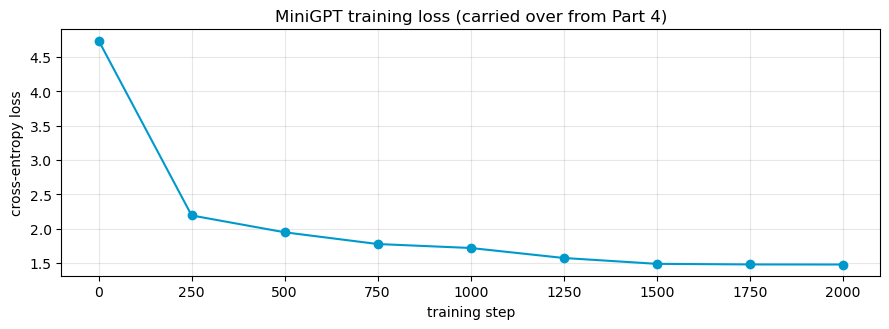

In [4]:
# Chart: the training loss curve carried over from Part 4 (or the fallback run).
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(train_curve[0], train_curve[1], "-o", color="#0099cc")
ax.set_title("MiniGPT training loss (carried over from Part 4)")
ax.set_xlabel("training step"); ax.set_ylabel("cross-entropy loss")
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Autoregressive generation</h4>
<p style="line-height:180%; font-size:medium;">
A trained GPT does not emit a sentence in one shot; it generates <b>one token at a time</b> in a loop. You feed it the current context, it returns logits over the whole vocabulary for the next position, you sample a single token from those logits, you append that token to the context, and you repeat. Because each new token is conditioned on the model's own previous outputs, the process is called <b>autoregressive</b>. One subtlety matters in practice: the context can only be as long as <code>block_size</code>, so before each step we crop the running sequence to its last <code>block_size</code> tokens with <code>idx[:, -block_size:]</code>. Everything else in decoding is about <i>how</i> you turn that final-position logit vector into a chosen token.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">2. How temperature reshapes the next-token distribution</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Before implementing anything, let us look at the model we just trained. We feed it the prompt <code>"ROMEO:"</code>, take the logits for the very next character, and apply three different temperatures. Dividing the logits by a temperature below one sharpens the distribution toward the single most likely token, while a temperature above one flattens it and gives rare tokens a real chance. This is the chart Nika opens her demo with.
</p>
</p>

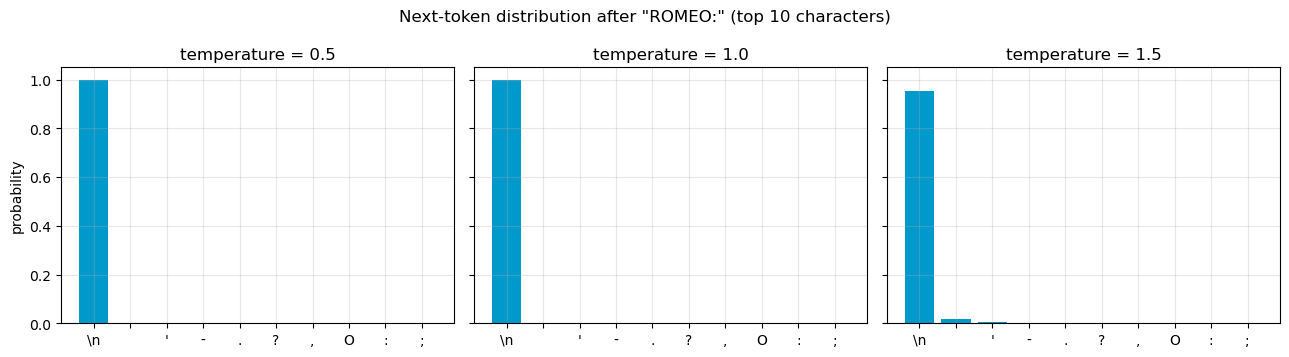

In [5]:
# Chart: the model's next-token distribution after "ROMEO:" at three temperatures.
_prompt = jnp.array([encode("ROMEO:")], dtype=jnp.int32)
_logits = model.apply(params, _prompt, deterministic=True)[0, -1, :]   # (vocab_size,)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for col, T in enumerate([0.5, 1.0, 1.5]):
    probs = np.array(jax.nn.softmax(_logits / T))
    top = np.argsort(-probs)[:10]
    ax[col].bar([repr(itos[int(t)])[1:-1] for t in top], probs[top], color="#0099cc")
    ax[col].set_title(f"temperature = {T}")
    ax[col].tick_params(axis="x", rotation=0)
ax[0].set_ylabel("probability")
fig.suptitle('Next-token distribution after "ROMEO:" (top 10 characters)')
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Top-k sampling</h4>
<p style="line-height:180%; font-size:medium;">
Even after temperature, the softmax still assigns a small but non-zero probability to every token in the vocabulary, and the accumulated mass of that long tail can occasionally produce nonsense. <b>Top-k sampling</b> is the simplest fix: keep only the <code>k</code> tokens with the highest logits and set every other logit to negative infinity, so that after softmax they receive exactly zero probability. The cut-off is a fixed count, which is easy to reason about but slightly rigid, because it keeps the same number of candidates whether the model is very sure or very unsure.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">3. Implement top-k filtering</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete <code>top_k_filter(logits, k)</code> for a batch of logit rows of shape <code>(batch, vocab)</code>. Find the <code>k</code>-th largest logit in each row (for example with <code>jnp.sort(logits, axis=-1)[:, -k]</code>), keep it as a column with <code>[:, None]</code>, and return <code>jnp.where(logits &lt; kth, -jnp.inf, logits)</code> so that everything below the threshold is masked out.
</p>
</p>

In [37]:
def top_k_filter(logits, k):
    # TODO: keep only the k highest logits per row; set the rest to -jnp.inf.
    #       Hint: kth = jnp.sort(logits, axis=-1)[:, -k][:, None]
    #             return jnp.where(logits < kth, -jnp.inf, logits)
    kth = jnp.sort(logits, axis=-1)[:, -k][:, None]
    return jnp.where(logits < kth, -jnp.inf, logits)

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Top-p (nucleus) sampling</h4>
<p style="line-height:180%; font-size:medium;">
<b>Top-p sampling</b>, also called <b>nucleus sampling</b>, replaces the fixed count of top-k with an adaptive one. You sort the tokens from most to least probable, walk down the list accumulating their probabilities, and keep just enough tokens for the cumulative mass to reach the threshold <code>p</code>; everything after that is discarded. When the model is confident a single token may already exceed <code>p</code>, so the nucleus is tiny, and when the model is unsure the nucleus grows to include many plausible options. This adaptivity is why most modern systems prefer top-p (often with <code>p &asymp; 0.9</code>) over a hard top-k.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">4. Implement top-p (nucleus) filtering</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete <code>top_p_filter(logits, p)</code>. Sort each row in descending order, convert the sorted logits to probabilities with softmax, and form the cumulative sum. Keep a token when the cumulative probability <i>before</i> it is still below <code>p</code> (that is, <code>(cum - probs) &lt; p</code>), which guarantees the first token is always kept and the nucleus just crosses the threshold. Finally scatter the keep-mask back to the original token order and return <code>jnp.where(mask, logits, -jnp.inf)</code>.
</p>
</p>

In [38]:
def top_p_filter(logits, p):
    # TODO: keep the smallest set of tokens whose cumulative probability exceeds p.
    #   order = jnp.argsort(logits, axis=-1)[:, ::-1]      # descending
    #   s     = jnp.take_along_axis(logits, order, axis=-1)
    #   probs = jax.nn.softmax(s, axis=-1)
    #   cum   = jnp.cumsum(probs, axis=-1)
    #   keep  = (cum - probs) < p ; keep = keep.at[:, 0].set(True)
    #   scatter keep back to original positions, then mask with -jnp.inf.
    order = jnp.argsort(logits, axis=-1)[:, ::-1]
    s = jnp.take_along_axis(logits, order, axis=-1)
    probs = jax.nn.softmax(s, axis=-1)
    cum = jnp.cumsum(probs, axis=-1)
    keep = (cum - probs) < p
    keep = keep.at[:, 0].set(True)
    rows = jnp.arange(logits.shape[0])[:, None]
    mask = jnp.zeros_like(logits, dtype=bool).at[rows, order].set(keep)
    return jnp.where(mask, logits, -jnp.inf)

OK: top_k_filter and top_p_filter behave as expected on the known distribution


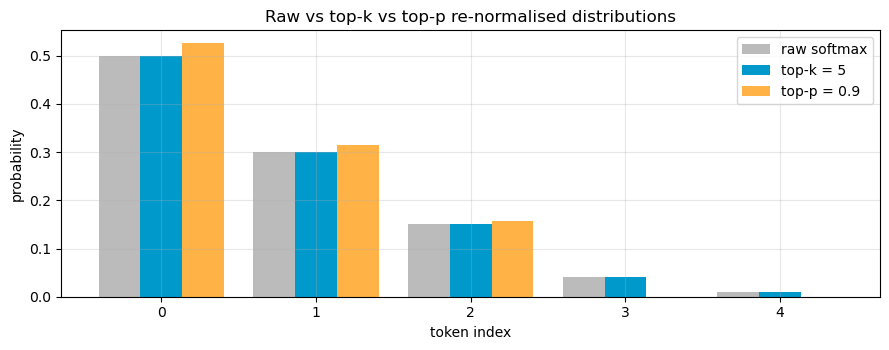

In [39]:
# Self-check on a KNOWN distribution, then a chart of the three filters side by side.
test = jnp.log(jnp.array([[0.5, 0.3, 0.15, 0.04, 0.01]]))   # probs are known by construction
assert int(jnp.isfinite(top_k_filter(test, 2)).sum()) == 2, "top-k=2 must keep exactly 2 tokens"
assert bool(jnp.all(jnp.isfinite(top_k_filter(test, 2))[0, :2])), "top-k=2 must keep the first 2"
assert int(jnp.isfinite(top_p_filter(test, 0.6)).sum()) == 2, "0.5+0.3 already passes 0.6 -> 2 tokens"
assert int(jnp.isfinite(top_p_filter(test, 0.9)).sum()) == 3, "0.5+0.3+0.15 passes 0.9 -> 3 tokens"
print("OK: top_k_filter and top_p_filter behave as expected on the known distribution")

base = np.array(jax.nn.softmax(test[0]))
pk = np.array(jax.nn.softmax(top_k_filter(test, 5)[0]))      # k=5 == full vocab here
pp = np.array(jax.nn.softmax(top_p_filter(test, 0.9)[0]))
x = np.arange(5); w = 0.27
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - w, base, w, label="raw softmax", color="#bbbbbb")
ax.bar(x,     pk,   w, label="top-k = 5", color="#0099cc")
ax.bar(x + w, pp,   w, label="top-p = 0.9", color="#ffb347")
ax.set_title("Raw vs top-k vs top-p re-normalised distributions")
ax.set_xlabel("token index"); ax.set_ylabel("probability"); ax.legend()
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; The KV cache: why generation is slow</h4>
<p style="line-height:180%; font-size:medium;">
Naive autoregressive generation is wasteful. To produce token <code>t</code> we feed the whole context of length <code>t</code> through every layer, and to produce token <code>t+1</code> we feed length <code>t+1</code> through every layer again, re-computing the keys and values for all the earlier positions even though they have not changed. The <b>KV cache</b> removes this waste: each layer stores the key and value vectors it has already computed, so every new step only computes the key, value, and query for the single newest token and attends against the cached past. This turns the per-step cost from growing with the sequence length into a constant, and it is the reason production inference servers can stream tokens quickly. Our teaching <code>generate</code> below recomputes from scratch for clarity, but the picture in the next cell shows what a real cache does.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">5. Implement autoregressive generation</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete <code>generate</code>. Loop <code>max_new_tokens</code> times; each step crop the context to the last <code>block_size</code> tokens, run the model, take the logits at the final position and divide them by <code>temperature</code>, optionally pass them through <code>top_k_filter</code> and/or <code>top_p_filter</code>, sample one token per row with <code>jax.random.categorical</code>, and append it to the running sequence. Use a fresh split of the PRNG key at every step so the samples are reproducible but not identical. The function relies on the global <code>model</code> defined above.
</p>
</p>

In [40]:
def generate(params, key, idx, max_new_tokens, block_size,
             temperature=1.0, top_k=None, top_p=None):
    # TODO: autoregressively sample max_new_tokens new tokens and append them to idx.
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]                 # crop to the last block_size tokens: idx[:, -block_size:]
        logits = model.apply(params, idx_cond, deterministic=True)[:, -1, :] / temperature  # model.apply(...)[:, -1, :] / temperature
        if top_k is not None:
            logits = top_k_filter(logits, top_k)        # top_k_filter(logits, top_k)
        if top_p is not None:
            logits = top_p_filter(logits, top_p)        # top_p_filter(logits, top_p)
        key, sk = jax.random.split(key)
        next_id = jax.random.categorical(sk, logits, axis=-1)[:, None]   # jax.random.categorical(sk, logits, axis=-1)[:, None]
        idx = jnp.concatenate([idx, next_id], axis=1)   # jnp.concatenate([idx, next_id], axis=1)
    return idx

In [41]:
# Self-check: shape of the generated sequence.
_start = jnp.array([encode("ROMEO:")], dtype=jnp.int32)
_out = generate(params, jax.random.PRNGKey(0), _start, 30, cfg["block_size"], temperature=1.0)
assert _out.shape == (1, _start.shape[1] + 30), "generate must append exactly max_new_tokens tokens"
print("OK: generate output shape =", tuple(_out.shape))

OK: generate output shape = (1, 36)


In [42]:
# Given: read 3-4 samples from the trained model at different decoding settings.
start = jnp.array([encode("ROMEO:")])
settings = [
    ("greedy-ish  T=0.5",              dict(temperature=0.5)),
    ("top-k=20    T=0.8",             dict(temperature=0.8, top_k=20)),
    ("top-p=0.9   T=1.0",            dict(temperature=1.0, top_p=0.9)),
    ("hot         T=1.4",              dict(temperature=1.4)),
]
for i, (name, kw) in enumerate(settings):
    out = generate(params, jax.random.PRNGKey(i), start, 200, cfg["block_size"], **kw)
    print("=" * 70); print(name)
    print("-" * 70); print(decode(out[0]))
print("=" * 70)

greedy-ish  T=0.5
----------------------------------------------------------------------
ROMEO:
What thou dost thou art of the king of the duke.

KING RICHARD II:
And the prince and the king.

CAPULET:
I have men in the ground, here is person the country.

HENRY BOLINGBROKE:
I can to not me to 
top-k=20    T=0.8
----------------------------------------------------------------------
ROMEO:
Some second to the weep to say make me,
Suffer and to heaven the contreats in my more
Than out then against the foe a little and by the chounds
It is the father with sweet the enemy and of much:
And 
top-p=0.9   T=1.0
----------------------------------------------------------------------
ROMEO:
How made farewellower?

GLOUCESTER:
Now, march, good stays him behim:
Though hast speed thee out of shall be conscurent.

DUCHESS OF YORK:
Brother the qualines and watching or lips.

CAPULET:
Condure
hot         T=1.4
----------------------------------------------------------------------
ROMEO:
So thou Warwick,

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">6. Decoding diversity as a function of temperature</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
To quantify the effect of the temperature dial, we generate a fixed-length sample at several temperatures and count how many <b>distinct</b> characters appear. Low temperatures collapse onto a handful of safe tokens, so the count is small; high temperatures spread the mass out, so the sample uses more of the vocabulary. This is the same trade-off Nika narrates live: safety versus surprise.
</p>
</p>

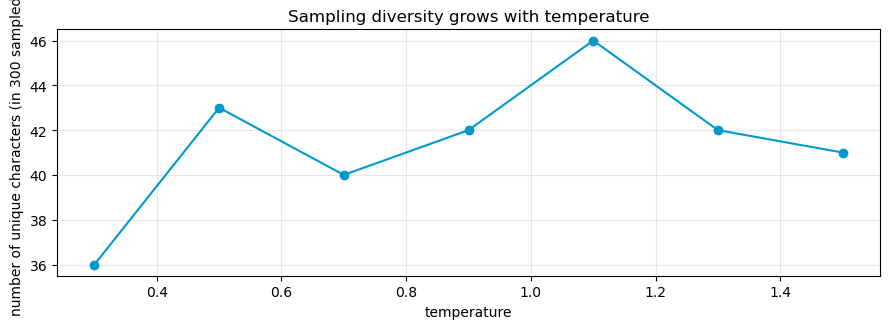

In [43]:
# Chart: sampling diversity (unique tokens) vs temperature.
temps = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]
uniques = []
for j, T in enumerate(temps):
    out = generate(params, jax.random.PRNGKey(100 + j), start, 300, cfg["block_size"], temperature=T)
    uniques.append(len(set(np.array(out[0, -300:]).tolist())))
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(temps, uniques, "-o", color="#0099cc")
ax.set_title("Sampling diversity grows with temperature")
ax.set_xlabel("temperature"); ax.set_ylabel("number of unique characters (in 300 sampled)")
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">7. A picture of the KV cache</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
The diagram below contrasts naive generation, which recomputes the keys and values for the whole prefix at every step, with cached generation, which stores them and only computes vectors for the newest token. The shaded boxes are the work that the cache lets you skip.
</p>
</p>

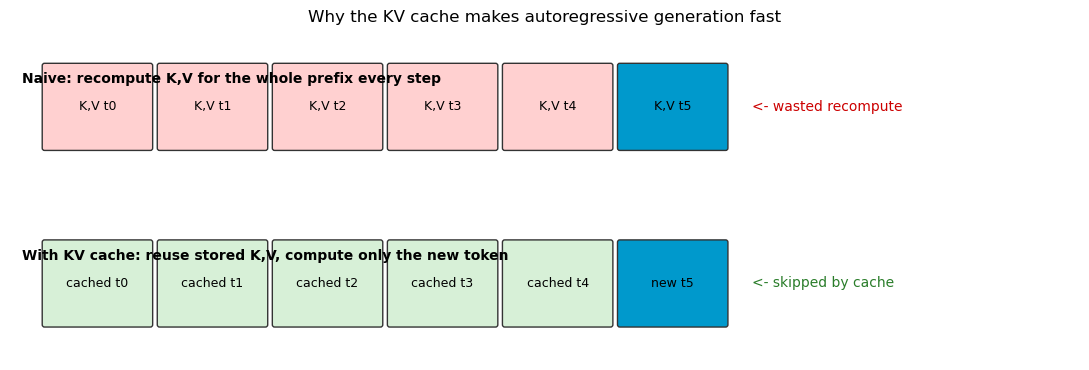

In [44]:
# Chart: a conceptual KV-cache diagram drawn with matplotlib boxes.
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(11, 3.8))
def box(x, y, label, fc, ec="#333"):
    ax.add_patch(FancyBboxPatch((x, y), 0.92, 0.7, boxstyle="round,pad=0.02", fc=fc, ec=ec))
    ax.text(x + 0.46, y + 0.35, label, ha="center", va="center", fontsize=9)
ax.text(-0.2, 2.55, "Naive: recompute K,V for the whole prefix every step", weight="bold")
for t in range(5):
    box(t, 2.0, f"K,V t{t}", "#ffd0d0")
box(5, 2.0, "K,V t5", "#0099cc")
ax.text(-0.2, 1.05, "With KV cache: reuse stored K,V, compute only the new token", weight="bold")
for t in range(5):
    box(t, 0.5, f"cached t{t}", "#d7f0d7")
box(5, 0.5, "new t5", "#0099cc")
ax.text(6.15, 2.35, "<- wasted recompute", color="#cc0000", va="center")
ax.text(6.15, 0.85, "<- skipped by cache", color="#2a7d2a", va="center")
ax.set_xlim(-0.3, 9); ax.set_ylim(0.2, 3.0); ax.axis("off")
ax.set_title("Why the KV cache makes autoregressive generation fast")
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Scaling laws: from MiniGPT to GPT-3</h4>
<p style="line-height:180%; font-size:medium;">
Our trained model has on the order of a hundred thousand parameters, while the GPT models that made headlines have millions to hundreds of billions. <b>Scaling laws</b> are the empirical finding that loss falls smoothly and predictably as you increase three things together: the number of parameters, the amount of training data, and the compute budget. GPT-2 came in sizes from 124 million up to 1.5 billion parameters, and GPT-3 pushed to 175 billion, trained on hundreds of billions of tokens. The architecture in those models is essentially the decoder-only Transformer you built in this lab; what changed was the scale, the data, and the engineering around it. The chart below puts our MiniGPT on the same logarithmic axis as the giants so the gap is concrete.
</p>
<div style="text-align:center;">
    <img src="images/openai_logo.svg" style="width:100%;">
</div>

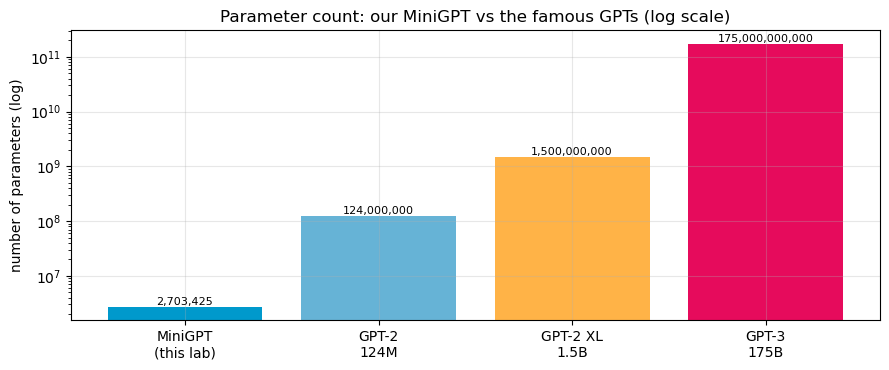

MiniGPT parameter count: 2,703,425


In [45]:
# Chart: parameter counts from MiniGPT to GPT-3 on a log scale.
# Count our model's parameters from the trained pytree.
mini_params = int(sum(x.size for x in jax.tree_util.tree_leaves(params)))
names  = ["MiniGPT\n(this lab)", "GPT-2\n124M", "GPT-2 XL\n1.5B", "GPT-3\n175B"]
counts = [mini_params, 124_000_000, 1_500_000_000, 175_000_000_000]
fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(names, counts, color=["#0099cc", "#66b3d6", "#ffb347", "#e60b5c"])
ax.set_yscale("log")
ax.set_title("Parameter count: our MiniGPT vs the famous GPTs (log scale)")
ax.set_ylabel("number of parameters (log)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{c:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
print("MiniGPT parameter count:", f"{mini_params:,}")

<div style="text-align:center;">
    <img src="images/transformer_full_architecture.png" width="700">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>The full Transformer. Every GPT, from our MiniGPT to GPT-3, is the decoder-only column scaled up; generation walks that column once per token.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#A62626">Learning note &mdash; Where to go next: a curated learning path</h4>
<p style="line-height:180%; font-size:medium;">
You have now built a decoder-only Transformer end to end and made it generate text. If you want to deepen the intuition with structured courses, the following short and long courses from DeepLearning.AI follow naturally from this lab.</p>
<ul style="line-height:200%; font-size:medium;">
<li><a href="https://www.deeplearning.ai/courses/how-transformer-llms-work">How Transformer LLMs Work</a> &mdash; a visual tour of the architecture you just implemented.</li>
<li><a href="https://www.deeplearning.ai/short-courses/attention-in-transformers-concepts-and-code-in-pytorch">Attention in Transformers: Concepts and Code in PyTorch</a> &mdash; the attention mechanism in depth.</li>
<li><a href="https://www.deeplearning.ai/courses/generative-ai-with-llms">Generative AI with LLMs</a> &mdash; the full lifecycle of training and deploying large models.</li>
<li><a href="https://www.deeplearning.ai/courses/transformers-in-practice">Transformers in Practice</a> &mdash; applying Transformers to real-world tasks.</li>
</ul>
<p style="line-height:180%; font-size:medium;">
</p>